In [1]:
import sys
sys.path.insert(0, '../iaml')

import pandas as pd

from iaml import *
from IPython.display import display, Markdown as IMarkdown, HTML as IHTML
from rich.console import Console
from rich.markdown import Markdown

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/0421485/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/0421485/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[06:10:15] cuDF not found: falling back to standalone pandas.

In [2]:
dataset = pd.read_csv('../perf_logger/tests_data/titanic.csv', delimiter=';')

In [3]:
dataset.shape

(891, 11)

In [4]:
autom = IAML(max_duration=300)

print(autom.default_pipeline())
print(autom.json_pipeline())

[06:10:17] Max duration under 500 seconds :                     Meta learner are disabled (you can enable it,      
           with the parameter 'metalearner')

           Max duration of each stage was set to 900 seconds

None
{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActDateConverter', 'name': 'Convert Short text to date if possible', 'description': 'Step description...', 'configuration': {'authorized_error_ratios': {'default': 0.05, 'description': 'Over this ratios, the column will not be converted into date', 'value': 0.05}, 'sample_size': {'default': 200, 'description': 'Convert date is time consuming.                     To save time, date detection will be done on a random sample.                     Set to -1 to detect on the whole dataset', 'value': 200}}, 'children': []}]}, {'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActWord2Vec', 'name': 'Word2Vec', 'description': 'Step description...', 'configuration': {}, 'children':

In [5]:
pipeline = {
    'step': 'MetaOrderedStep',
    'children': [
        {
            'step': 'MetaStep',
            'tag': 'cleaning',
        },
        {
            'step': 'MetaStep',
            'tag': 'features_selection',
        },
        # {
        #    'step': 'WrapKFold',
        #    'children': [{
            #    'step': 'ActKNN',
        #    }]
        # },
    ]
}

# autom.load_pipeline(pipeline)
print(autom.json_pipeline())


{'step': 'MetaOrderedStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActDateConverter', 'name': 'Convert Short text to date if possible', 'description': 'Step description...', 'configuration': {'authorized_error_ratios': {'default': 0.05, 'description': 'Over this ratios, the column will not be converted into date', 'value': 0.05}, 'sample_size': {'default': 200, 'description': 'Convert date is time consuming.                     To save time, date detection will be done on a random sample.                     Set to -1 to detect on the whole dataset', 'value': 200}}, 'children': []}]}, {'step': 'MetaStep', 'name': 'MetaStep', 'description': 'Step description...', 'configuration': {}, 'children': [{'step': 'ActWord2Vec', 'name': 'Word2Vec', 'description': 'Step description...', 'configuration': {}, 'children': []},

In [6]:
results = autom.fit(
    dataset.drop('label', axis=1).copy(),
    dataset[['label']]).copy()

Output()

[06:10:21] running step: MetaOrderedStep (steps=MetaExplorerStep,MetaPartialExplorerStep,MetaStep)

           running step: MetaStep (steps=ActDateConverter)

           running step: MetaStep                                                                                  
           (steps=ActDropTextualColumn,ActTfIdf,ActWord2Vec,ActDropNumericalColumn,ActDropDateColumn,ActSplitDate,A
           ctMeanColumn,ActOnehot)

           running step: MetaStep (steps=ActRemoveHighCorrelatedColumn)

...

[06:15:20] gen4,             Nb mutation=31,             Nb random=0

           Finetuning...                 stage=3                 candidates=17                 patience=2/-1,      
           duration=233.93/234.63364067673683,                 best_result=0.8127105032824312

           0.6771641080553772 : ['Convert Short text to date if possible', 'Fill missing values with mean',        
           'Transform string column to date', 'One hot encoding categorical features', 'TF-IDF', 'Drop date        
           columns', 'Drop numerical columns', 'Drop textual columns', 'Remove High Correlated Column', 'Min Max   
           Scaler', 'Approximate with RBFSampler', 'Learn : MLP Classifier']

           gen5,             Nb mutation=31,             Nb random=0

           Finetuning...                 stage=4                 candidates=19                 patience=3/-1,      
           duration=234.23/234.63364067673683,                 best_result=0.8127105032824312

('Learn : SVM Classification', <iaml.actionables.predictors.act_svm_svc.ActSVMSVC object at 0x7f62d0c2f610>)
[('Convert Short text to date if possible', <iaml.actionables.features_precleaning.act_date_converter.ActDateConverter object at 0x7f62d0d4c820>), ('Fill missing values with mean', <iaml.actionables.cleaning.act_mean_column.ActMeanColumn object at 0x7f62d0d4eef0>), ('Transform string column to date', <iaml.actionables.cleaning.act_split_date.ActSplitDate object at 0x7f62d0d4d930>), ('One hot encoding categorical features', <iaml.actionables.cleaning.act_onehot.ActOnehot object at 0x7f62d0d4d2a0>), ('TF-IDF', <iaml.actionables.cleaning.act_tf_idf.ActTfIdf object at 0x7f62d0d4c430>), ('Drop date columns', <iaml.actionables.cleaning.act_drop_date_column.ActDropDateColumn object at 0x7f62d0d4ece0>), ('Drop numerical columns', <iaml.actionables.cleaning.act_drop_numerical_column.ActDropNumericalColumn object at 0x7f62d0d4e500>), ('Drop textual columns', <iaml.actionables.cleaning.act


## Fill missing values with mean
**Fills missing values with the mean of non-missing values
        when the proportion of empty rows is lower than {empty_threshold}.**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **empty_threshold** | Column with less or equal proportion of empty row will                     be fill with mean value. 1 will always fill void values | 1 |



### Processings
 - Filled missing values of column **`Pclass`** with **2.31**
                (**0** out of **891** values (**0.00**%)
                were missing in train data).
 - Filled missing values of column **`Age`** with **29.70**
                (**177** out of **891** values (**19.87**%)
                were missing in train data).
 - Filled missing values of column **`SibSp`** with **0.52**
                (**0** out of **891** values (**0.00**%)
                were missing in train data).
 - Filled missing values of column **`Parch`** with **0.38**
                (**0** out of **891** values (**0.00**%)
                were missing in train data).
 - Filled missing values of column **`Fare`** with **32.20**
                (**0** out of **891** values (**0.00**%)
                were missing in train data).


        


## One hot encoding categorical features
**Step description...**




### Processings
 - Encoded categorical column **`Sex`** into **2** new columns.
 - Encoded categorical column **`Embarked`** into **4** new columns.


        


## TF-IDF
**Step description...**




### Processings
 - Encoded text column **`Name`** into **1509** new columns.
 - Encoded text column **`Ticket`** into **695** new columns.
 - Encoded text column **`Cabin`** into **158** new columns.


        


## Remove High Correlated Column
**Remove columns which correlation with other columns is higher than {threshold}.**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **threshold** | If two columns is correlated over this value, only one                     will be kept | 0.9 |



### Processings
 - Dropped column **`Sex_male`** because it was too correlated with
                **`Sex_female`**.
 - Dropped column **`Name_amanda`** because it was too correlated with
                **`Name_adolfina`**.
 - Dropped column **`Name_antino`** because it was too correlated with
                **`Name_aijo`**.
 - Dropped column **`Name_asim`** because it was too correlated with
                **`Name_adola`**.
 - Dropped column **`Name_aurora`** because it was too correlated with
                **`Name_adelia`**.
 - Dropped column **`Name_banoura`** because it was too correlated with
                **`Name_ayoub`**.
 - Dropped column **`Name_barah`** because it was too correlated with
                **`Name_assi`**.
 - Dropped column **`Name_barkworth`** because it was too correlated with
                **`Name_algernon`**.
 - Dropped column **`Name_bazzani`** because it was too correlated with
                **`Name_albina`**.
 - Dropped column **`Name_berthe`** because it was too correlated with
                **`Name_antonine`**.
 - Dropped column **`Name_blyler`** because it was too correlated with
                **`Name_billiard`**.
 - Dropped column **`Name_bratthammer`** because it was too correlated with
                **`Name_bernt`**.
 - Dropped column **`Name_butt`** because it was too correlated with
                **`Name_archibald`**.
 - Dropped column **`Name_cassem`** because it was too correlated with
                **`Name_albimona`**.
 - Dropped column **`Name_cerin`** because it was too correlated with
                **`Name_balkic`**.
 - Dropped column **`Name_chip`** because it was too correlated with
                **`Name_chang`**.
 - Dropped column **`Name_christine`** because it was too correlated with
                **`Name_carla`**.
 - Dropped column **`Name_chronopoulos`** because it was too correlated with
                **`Name_apostolos`**.
 - Dropped column **`Name_clear`** because it was too correlated with
                **`Name_cameron`**.
 - Dropped column **`Name_cornelia`** because it was too correlated with
                **`Name_alma`**.
 - *and **1102** more explanations...*

        

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/68 [00:00<?, ?it/s]

/stockage/hr/automl/.venv/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=2.660e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/stockage/hr/automl/.venv/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=5.669e-03, with an active set of 8 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/stockage/hr/automl/.venv/lib/python3.10/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=5.467e-03, with an active set of 8 regressors, an


## Learn : SVM Classification
**Step description...**


### Configuration
| Name | Description | Value |
| ---- | ----------- | ----- |
| **kernel** | Kernel to use in the SVM | rbf |
| **random_state** | random_state | 42 |
| **class_weight** | Can be set on "balenced" to improve results on unbalenced data | None |
| **tol** | The stopping criterion. | 0.001 |
        



### Features impact
| Feature | Mean impact (SHAP value) |
| ------- | ------------------------ |
| `Pclass` | **0.060** |
| `Name` | **0.155** |
| `Sex` | **0.156** |
| `Age` | **0.017** |
| `SibSp` | **0.020** |
| `Parch` | **0.008** |
| `Ticket` | **0.023** |
| `Fare` | **0.005** |
| `Cabin` | **0.008** |
| `Embarked` | **0.035** |


### SHAP plots


#### Force plot
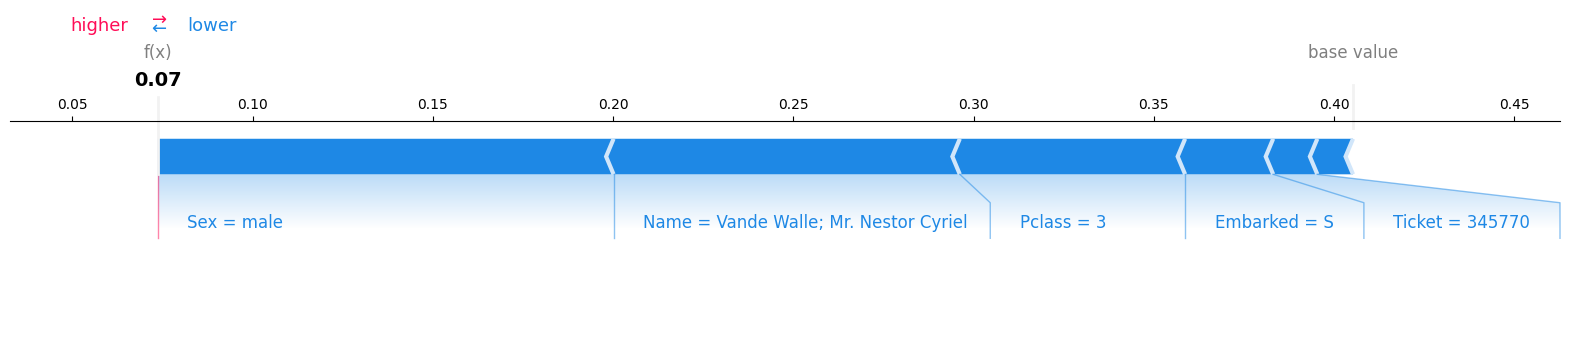

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.126**.*



#### Waterfall plot
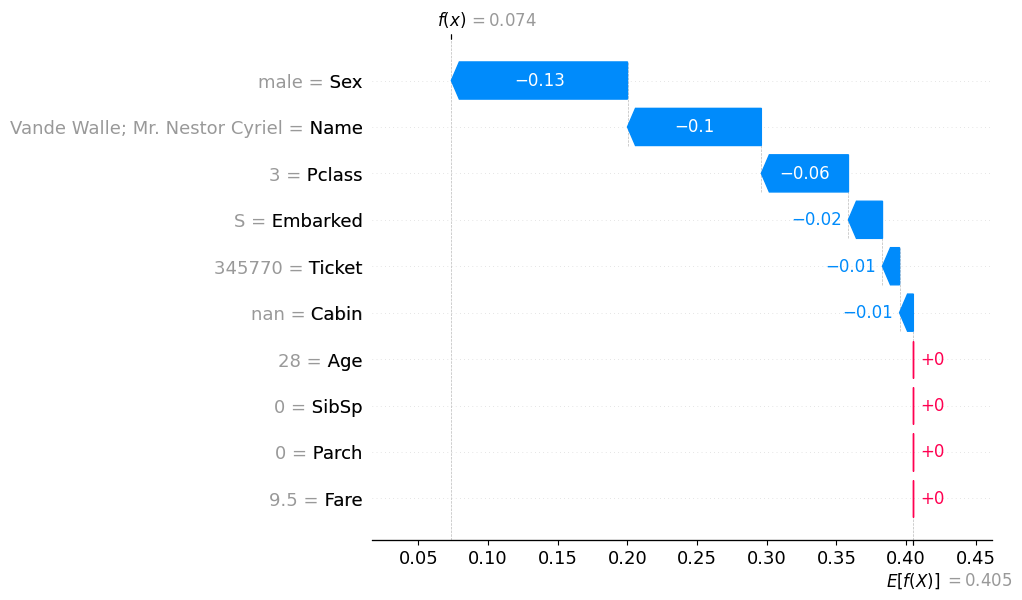

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.126**.*



#### Beeswarm plot
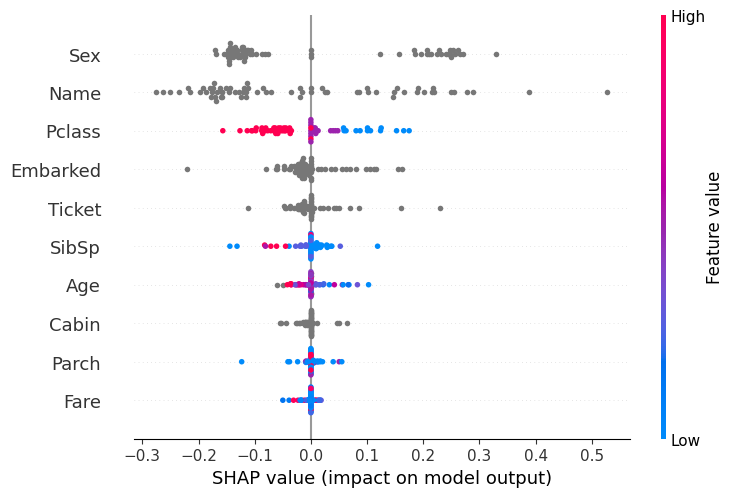



#### Heatmap plot
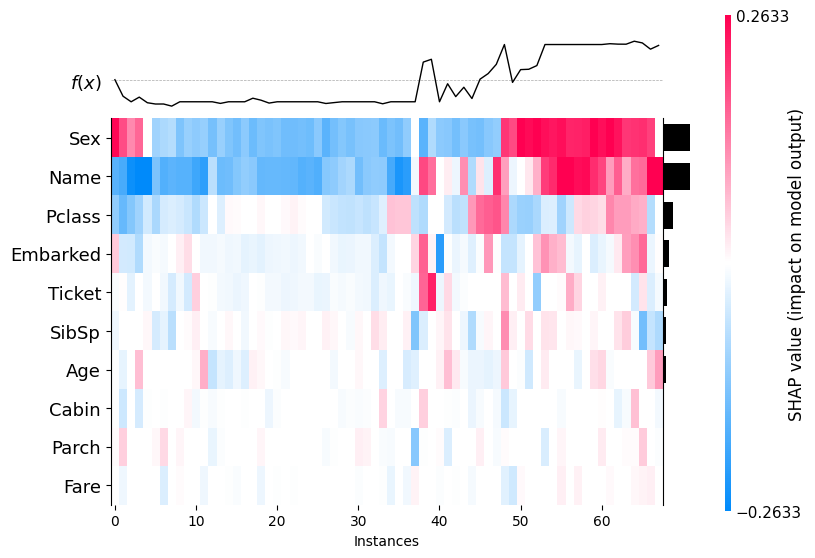



#### Scatter plot
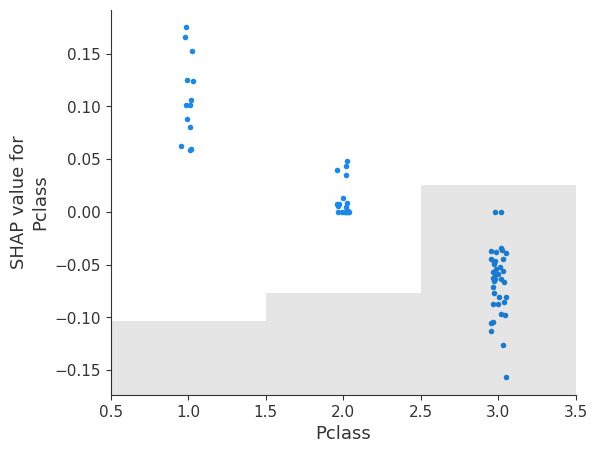



#### Bar plot
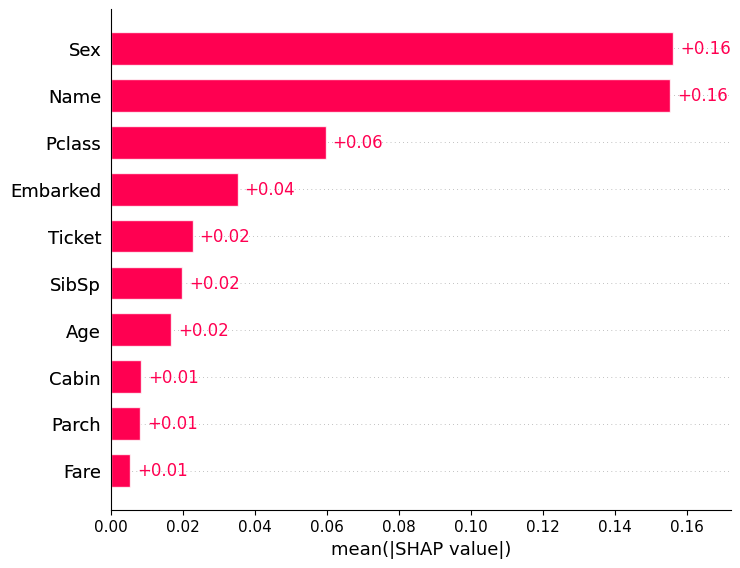

***Reading**: `Sex` has an absolute impact of **0.156** on the average final prediction value.*


        

In [7]:
print(results[0].pipeline.model)
print(results[0].pipeline.steps)

console = Console()

for step in results[0].pipeline.explanations:
    if step:
        display(IMarkdown(step))

test = dataset.iloc[200:(200+68)].drop('label', axis=1).copy()

pm = results[0].pipeline.pickle()

md = autom.chosen_candidate.pipeline.explain_model(test)
display(IMarkdown(md.to_markdown(plots=['force', 'waterfall', 'scatter', 'beeswarm', 'heatmap', 'bar'])))


### SHAP plots


#### Force plot
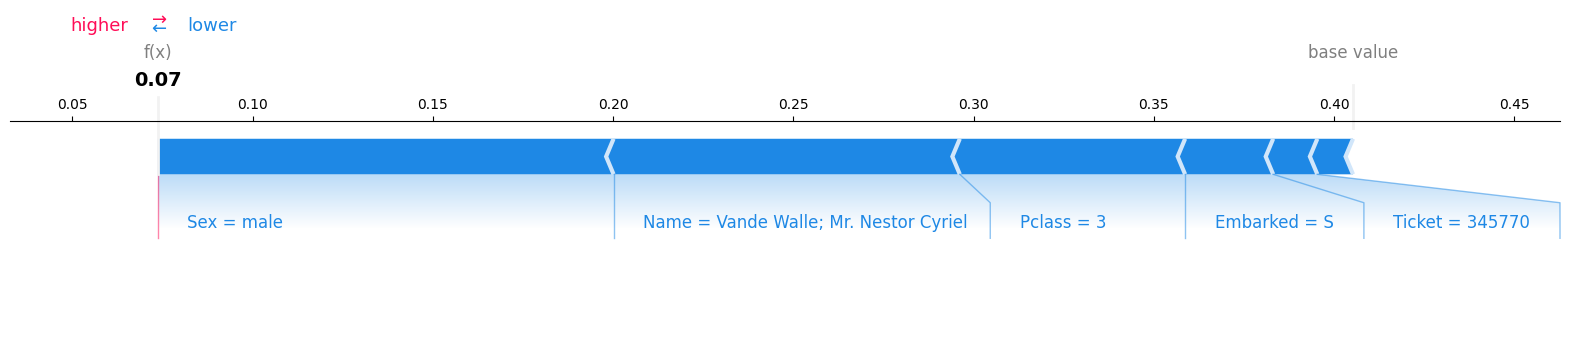

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.126**.*



#### Waterfall plot
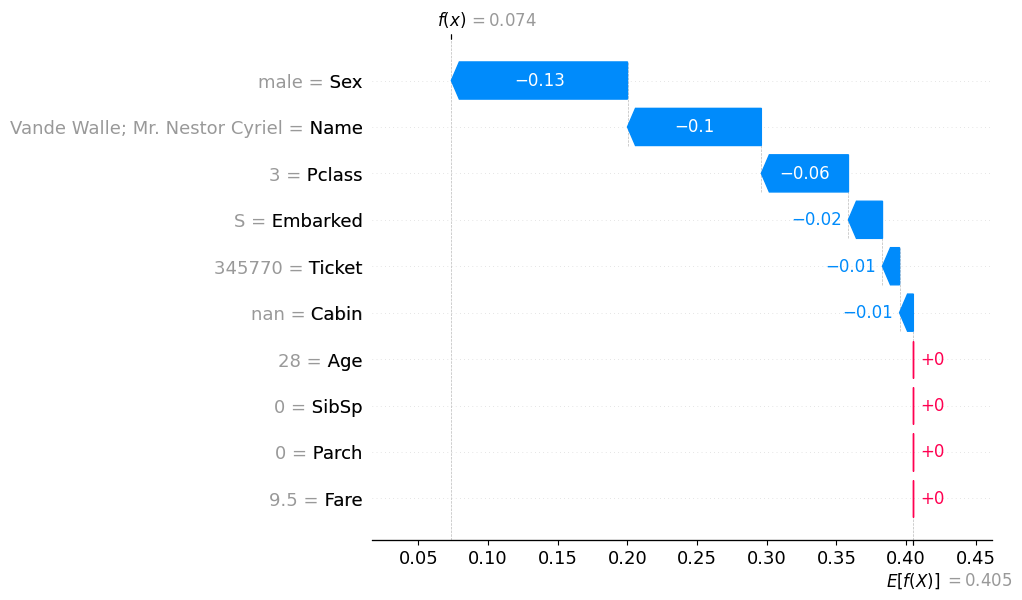

***Reading**: For this prediction, `Sex` impacts the final prediction value by **-0.126**.*



#### Beeswarm plot
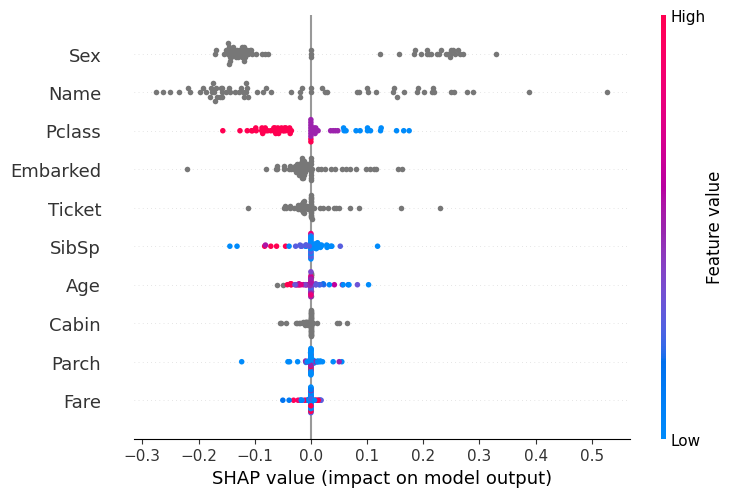



#### Heatmap plot
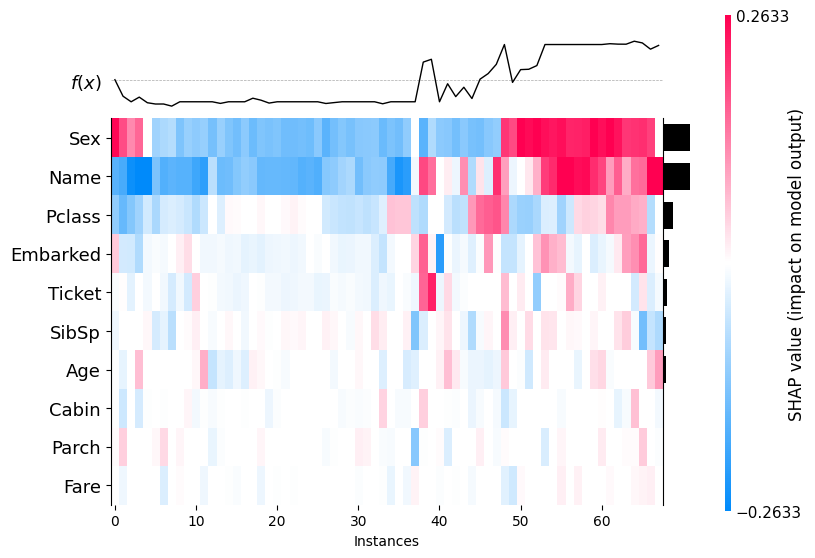



#### Scatter plot
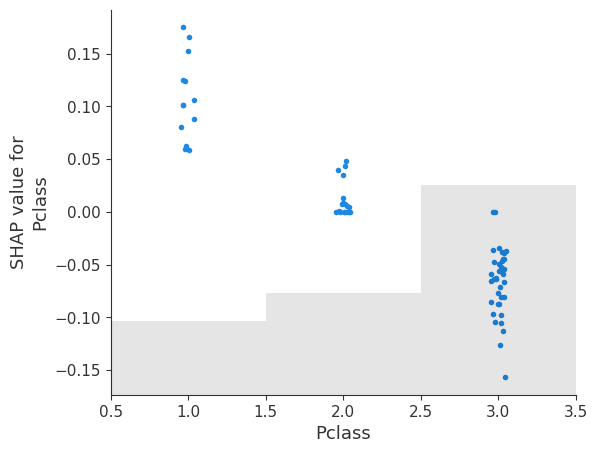



#### Bar plot
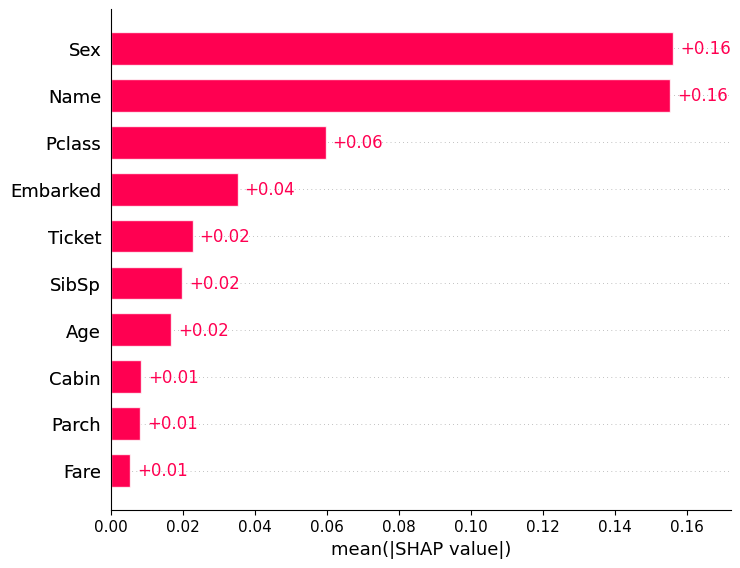

***Reading**: `Sex` has an absolute impact of **0.156** on the average final prediction value.*



In [8]:
display(IMarkdown(md.to_markdown_plots()))

In [9]:
md.to_b64_plots()

[('force',
  '...'),
 ('waterfall',
  '...'),
 ('beeswarm',
  '...'),
 ('scatter',
  '...'),
 ('heatmap',
  '...'),
 ('bar',
  '...')]

In [ ]:
import pickle

o = 0 # offset
n = 68  # # of samples
labels = dataset.iloc[o:(o+n)]['label']
predict_df = dataset.iloc[o:(o+n)].drop('label', axis=1).copy()

# labels = labels.reset_index()
predict_df.reset_index(inplace=True, drop=True)

m = pickle.loads(pm)
sum([ r == labels.iloc[o+i] for i, r in enumerate(m.predict(predict_df)) ]) / n

In [ ]:
final_boss_iaml = IAML(max_workers=2)
final_boss_iaml.default_pipeline()
final_boss_results = final_boss_iaml.fit(dataset.drop('label', axis=1).copy(), dataset[['label']].copy())

In [ ]:
# sum([ len(r.model.pickle()) for r in final_boss_results ])
[ (r.model.ml_model, r.evaluate()) for r in final_boss_results if r.model.ml_model is not None ]